# Static Discretization Analysis

> Goal: evaluate how discretizing continuous values into a finite menu of prices impacts revenue loss and runtime.

This notebook compares three discretization strategies implemented in the project:
- Uniform (arithmetic) grid
- Geometric (multiplicative) grid
- DP Optimal grid (exact minimizer via dynamic programming)

It is organized in two parts:
1. Single-K comparison (distribution and one-shot losses)
2. Convergence analysis over increasing number of bins $K$

In [16]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we can import from the src directory
sys.path.append(os.path.dirname(os.getcwd()))
from src.discretizer import Discretizer

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Environment And Imports

This setup cell loads plotting and data libraries and imports the project `Discretizer` class from the source package.
All downstream cells depend on these imports.

In [17]:
# Load the fully processed batch
data_path = os.path.join("..", "data", "processed", "static_batch_may2019_new.csv")
df = pd.read_csv(data_path)

# Enforce Individual Rationality: keep only jobs with positive virtual rate
# Jobs with phi_rate <= 0 are mathematically rejected by the mechanism
valid_df = df[df['phi_rate'] > 0].copy()

# Separate the two value spaces
v_continuous   = valid_df['v_rate'].values    # true hourly valuation rate
phi_continuous = valid_df['phi_rate'].values  # virtual hourly rate (mechanism input)
q_j            = valid_df['q_j'].values

LAMBDA_2 = 1.0
max_financial_continuous = float(np.sum(v_continuous))
max_objective_continuous = float(np.sum(LAMBDA_2 * q_j * phi_continuous))

print(f"Total jobs requested:                    {len(df)}")
print(f"Jobs accepted by mechanism (phi_rate>0): {len(valid_df)}")
print(f"Maximum theoretical revenue (sum v_rate):     ${max_financial_continuous:.2f}")
print(f"Maximum objective score (λ·q_j·phi_rate): {max_objective_continuous:.4f}")

Total jobs requested:                    1977
Jobs accepted by mechanism (phi_rate>0): 1402
Maximum theoretical revenue (sum v_rate):     $5418.98
Maximum objective score (λ·q_j·phi_rate): 70627.9604


## Data Scope and Mechanism Filter

We load `static_batch_may2019_new.csv` and keep only jobs with `phi_rate > 0`.
This matches the mechanism's IR boundary: jobs with a non-positive virtual rate are excluded from allocation and generate no revenue.

- **`v_rate`**: the true hourly valuation rate each user would be willing to pay — the financial metric.
- **`phi_rate`**: the Myerson virtual rate — the algorithmic metric the mechanism optimises over.

The printed sums are the theoretical upper bounds achievable with a continuous (infinite-resolution) price menu.

---

**Terminology: Mice and Whales.**
Throughout this notebook, jobs are informally split into two populations based on their resource demand and valuation:

- **Mice** — the vast majority of jobs (roughly the bottom 95% by `v_rate`). These are small, short, or low-value workloads: cron jobs, lightweight batch tasks, monitoring agents. They cluster densely near zero in the `phi_rate` distribution and individually contribute little revenue, but they are so numerous that their aggregate loss matters.
- **Whales** — the top ~5% of jobs by `v_rate`. These are large, long-running, high-priority workloads: ML training runs, large-scale data pipelines, latency-sensitive production services. Each whale has a high true valuation and a large `phi_rate`, so a single coarse bin placement can cause a disproportionate per-job revenue loss.

In [18]:
K_BINS = 16
discretizer = Discretizer(K_bins=K_BINS)

results = []

# --- 1. Uniform Grid ---
start_time = time.perf_counter()
uniform_disc_v   = discretizer.uniform_grid(v_continuous)
uniform_disc_phi = discretizer.uniform_grid(phi_continuous)
uniform_time = time.perf_counter() - start_time

uniform_fin_loss, uniform_v_cont, uniform_v_disc = discretizer.calculate_financial_loss(
    v_continuous, uniform_disc_v, return_details=True)
uniform_obj_loss = discretizer.calculate_objective_loss(
    phi_continuous, uniform_disc_phi, q_j, lambda_2=LAMBDA_2)
results.append({
    "Method": "Uniform",
    "Extracted Revenue ($)": uniform_v_disc,
    "Financial Loss ($)": uniform_fin_loss,
    "Financial Loss (%)": uniform_fin_loss / max_financial_continuous * 100,
    "Extracted Objective": float(np.sum(LAMBDA_2 * q_j * uniform_disc_phi)),
    "Objective Loss": uniform_obj_loss,
    "Objective Loss (%)": uniform_obj_loss / max_objective_continuous * 100,
    "Time (s)": uniform_time,
})

# --- 2. Geometric Grid ---
start_time = time.perf_counter()
geometric_disc_v   = discretizer.geometric_grid(v_continuous)
geometric_disc_phi = discretizer.geometric_grid(phi_continuous)
geometric_time = time.perf_counter() - start_time

geometric_fin_loss, geometric_v_cont, geometric_v_disc = discretizer.calculate_financial_loss(
    v_continuous, geometric_disc_v, return_details=True)
geometric_obj_loss = discretizer.calculate_objective_loss(
    phi_continuous, geometric_disc_phi, q_j, lambda_2=LAMBDA_2)
results.append({
    "Method": "Geometric",
    "Extracted Revenue ($)": geometric_v_disc,
    "Financial Loss ($)": geometric_fin_loss,
    "Financial Loss (%)": geometric_fin_loss / max_financial_continuous * 100,
    "Extracted Objective": float(np.sum(LAMBDA_2 * q_j * geometric_disc_phi)),
    "Objective Loss": geometric_obj_loss,
    "Objective Loss (%)": geometric_obj_loss / max_objective_continuous * 100,
    "Time (s)": geometric_time,
})

# --- 3. DP Optimal Grid ---
start_time = time.perf_counter()
dp_disc_v   = discretizer.dp_optimal_grid(v_continuous)
dp_disc_phi = discretizer.dp_optimal_grid(phi_continuous)
dp_time = time.perf_counter() - start_time

dp_fin_loss, dp_v_cont, dp_v_disc = discretizer.calculate_financial_loss(
    v_continuous, dp_disc_v, return_details=True)
dp_obj_loss = discretizer.calculate_objective_loss(
    phi_continuous, dp_disc_phi, q_j, lambda_2=LAMBDA_2)
results.append({
    "Method": "DP Optimal",
    "Extracted Revenue ($)": dp_v_disc,
    "Financial Loss ($)": dp_fin_loss,
    "Financial Loss (%)": dp_fin_loss / max_financial_continuous * 100,
    "Extracted Objective": float(np.sum(LAMBDA_2 * q_j * dp_disc_phi)),
    "Objective Loss": dp_obj_loss,
    "Objective Loss (%)": dp_obj_loss / max_objective_continuous * 100,
    "Time (s)": dp_time,
})

results_df = pd.DataFrame(results)
display(results_df)

,Method,Extracted Revenue ($),Financial Loss ($),Financial Loss (%),Extracted Objective,Objective Loss,Objective Loss (%),Time (s)
0,Uniform,3175.736657,2243.241849,41.396028,25348.832602,45279.127767,64.109352,0.001122
1,Geometric,3466.549159,1952.429347,36.029472,45676.939669,24951.020699,35.327398,0.000856
2,DP Optimal,4756.000627,662.977879,12.234370,57613.325361,13014.635007,18.427029,0.886547


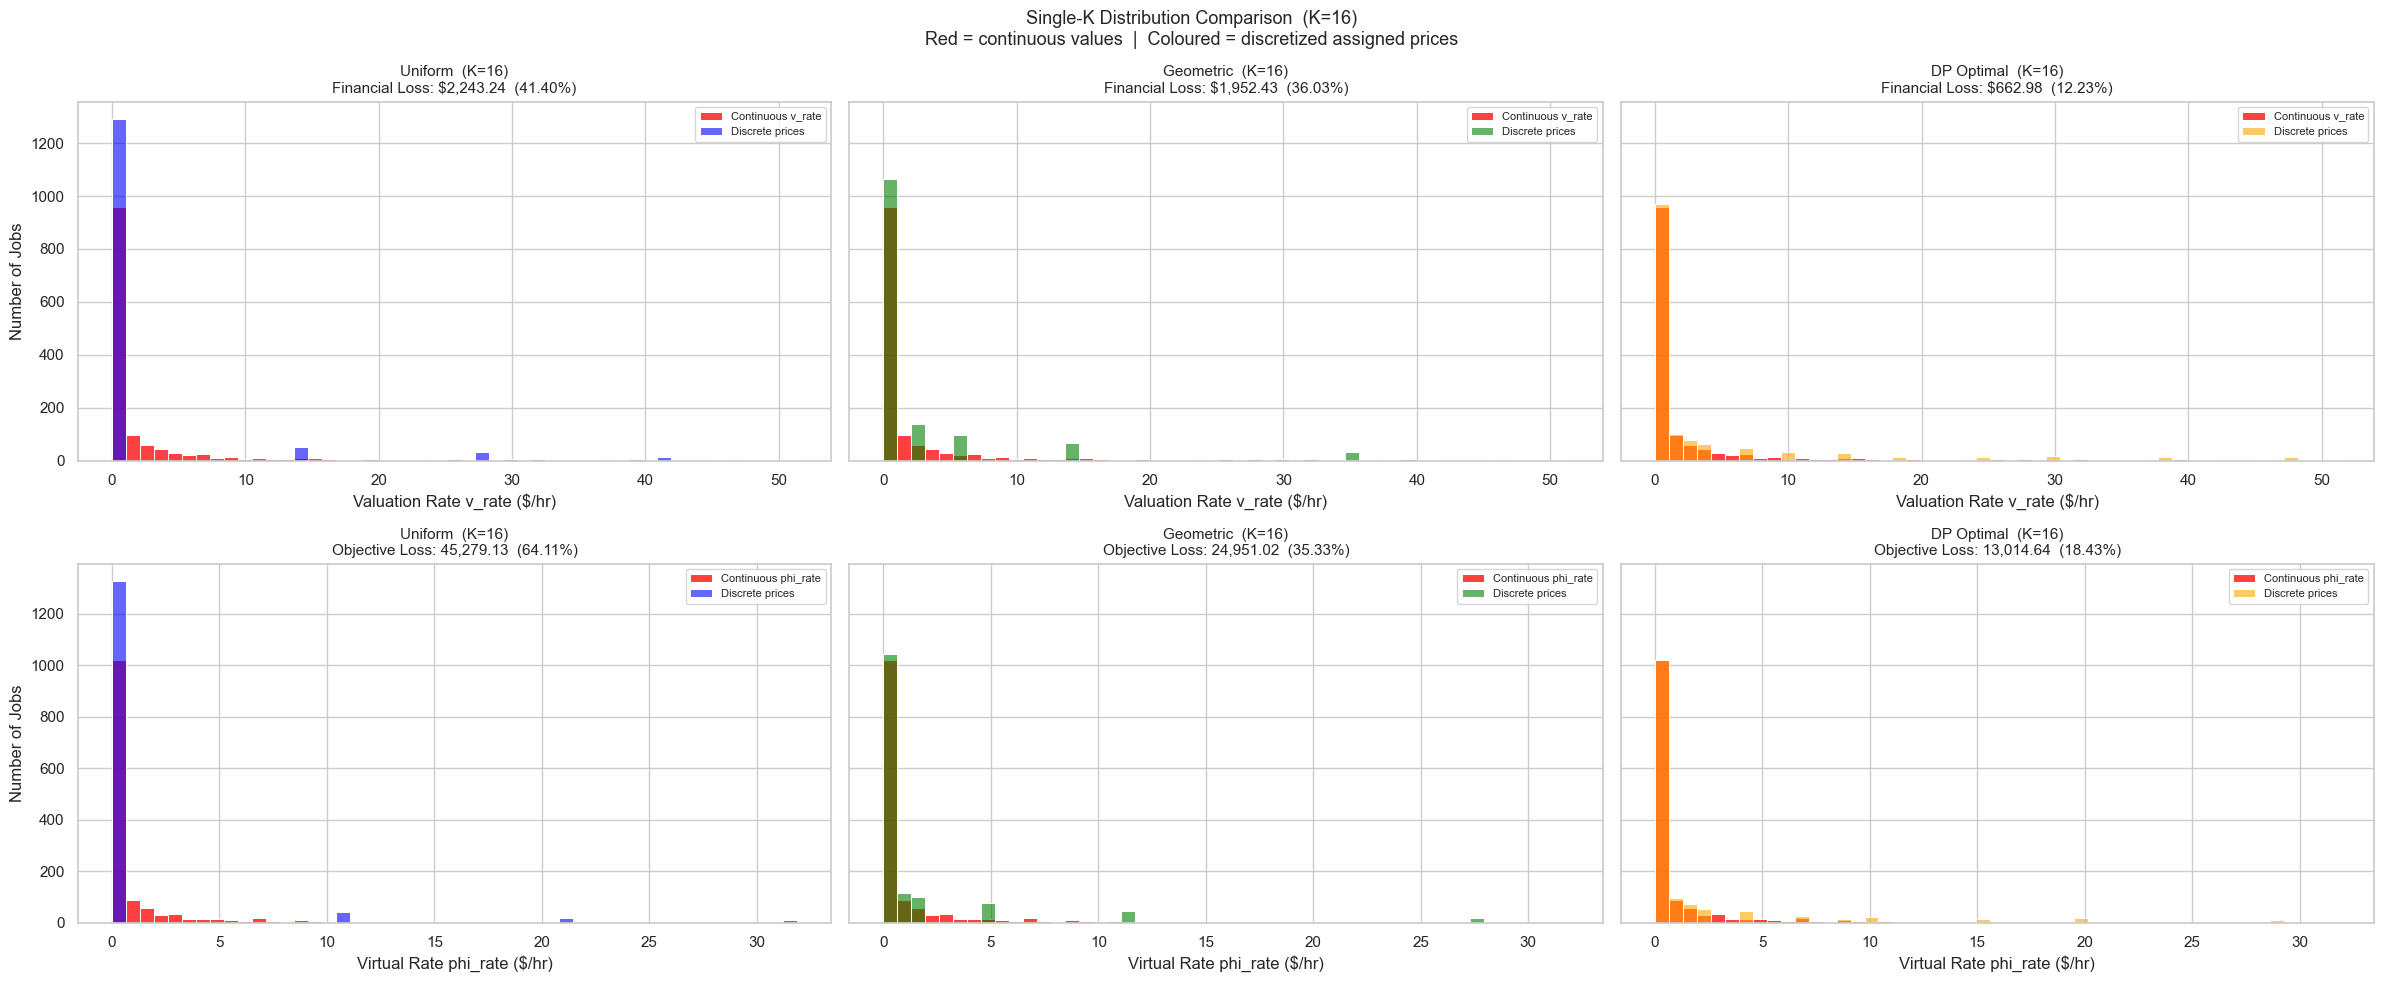

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(24, 10), sharey='row')

v_bins   = np.linspace(0, np.percentile(v_continuous,   99), 50)
phi_bins = np.linspace(0, np.percentile(phi_continuous, 99), 50)

method_configs = [
    ("Uniform",   uniform_disc_v,   uniform_disc_phi,   "blue",
     uniform_fin_loss,    uniform_fin_loss / max_financial_continuous * 100,
     uniform_obj_loss,    uniform_obj_loss / max_objective_continuous * 100),
    ("Geometric", geometric_disc_v, geometric_disc_phi, "green",
     geometric_fin_loss,  geometric_fin_loss / max_financial_continuous * 100,
     geometric_obj_loss,  geometric_obj_loss / max_objective_continuous * 100),
    ("DP Optimal", dp_disc_v,       dp_disc_phi,        "orange",
     dp_fin_loss,         dp_fin_loss / max_financial_continuous * 100,
     dp_obj_loss,         dp_obj_loss / max_objective_continuous * 100),
]

for col, (name, disc_v, disc_phi, color, fl, fl_pct, ol, ol_pct) in enumerate(method_configs):
    # Top row: v_rate space
    sns.histplot(v_continuous, bins=v_bins, color='red',  label='Continuous v_rate', ax=axes[0, col], stat='count')
    sns.histplot(disc_v,       bins=v_bins, color=color, alpha=0.6, label='Discrete prices', ax=axes[0, col], stat='count')
    axes[0, col].set_title(f"{name}  (K={K_BINS})\nFinancial Loss: ${fl:,.2f}  ({fl_pct:.2f}%)", fontsize=11)
    axes[0, col].set_xlabel("Valuation Rate v_rate ($/hr)")
    axes[0, col].set_ylabel("Number of Jobs" if col == 0 else "")
    axes[0, col].legend(fontsize=8)

    # Bottom row: phi_rate space
    sns.histplot(phi_continuous, bins=phi_bins, color='red',  label='Continuous phi_rate', ax=axes[1, col], stat='count')
    sns.histplot(disc_phi,       bins=phi_bins, color=color, alpha=0.6, label='Discrete prices', ax=axes[1, col], stat='count')
    axes[1, col].set_title(f"{name}  (K={K_BINS})\nObjective Loss: {ol:,.2f}  ({ol_pct:.2f}%)", fontsize=11)
    axes[1, col].set_xlabel("Virtual Rate phi_rate ($/hr)")
    axes[1, col].set_ylabel("Number of Jobs" if col == 0 else "")
    axes[1, col].legend(fontsize=8)

plt.suptitle(f"Single-K Distribution Comparison  (K={K_BINS})\nRed = continuous values  |  Coloured = discretized assigned prices", fontsize=13)
plt.tight_layout()
plt.show()

## Distribution-Level Comparison at Fixed K

Each panel overlays the continuous value distribution (red) with the discrete prices assigned by each algorithm (coloured). The top row works in `v_rate` space (financial metric); the bottom row works in `phi_rate` space (algorithmic/objective metric).

**Why the Uniform grid shows fewer than K=16 colours.** The uniform grid divides [min, max] into K equal-width bins of ~10.44 $/hr each. Because `phi_rate` is extremely right-skewed (p50 = 0.08, p90 = 4.83, p95 = 10.73), **95 % of jobs fall into the very first bin** and 7 of the 16 bins in the right tail contain zero jobs. A bin with no jobs assigned produces no bar in the plot and no entry in the legend — so only 9 distinct prices are visible. This is not a bug: it is the exact failure mode the analysis is designed to expose. Geometric and DP always populate all 16 bins because their boundary spacing adapts to the data range.

**How to read the overlap.** When the coloured bars closely follow the red bars, the discretization error is small. A single towering coloured spike (Uniform, leftmost bin) signals that ~1,300 jobs are all charged the same rock-bottom price regardless of their true valuation — the dominant source of revenue loss. Geometric spreads jobs more evenly but leaves the right tail coarsely covered. DP achieves the tightest match across the full distribution.

## Convergence Study Across K

We sweep K from 2 to a method-specific upper limit and record financial loss, objective loss, and execution time at each step.

**Early-stopping rule.** The sweep uses a marginal improvement threshold of **0.1 %**: if the percentage reduction in financial loss from one K to the next (`(loss_prev − loss_curr) / loss_prev × 100`) drops below 0.1 %, the loop exits early. This is implemented via the `target_threshold_pct=0.1` parameter passed to `run_convergence_test` and applies identically to all three methods.

**Why DP does not stop early.** For DP the per-step improvement remains well above 0.1 % throughout the entire sweep (from ~35 % at K=4 down to ~7.5 % at K=30). DP is genuinely still extracting significant value from every additional bin — it never reaches diminishing returns within the tested range. The sweep is hard-capped at `max_k=30` for a purely computational reason: DP is O(K·N²), which becomes prohibitive for larger K.

**Why Uniform and Geometric do stop early.** Their loops exit, but not because of graceful convergence — inspection shows the marginal improvement goes slightly **negative** at the stopping point (Uniform: −1.2 %, Geometric: −4.3 %). Since a negative value is below the 0.1 % threshold the condition fires. The exit is valid — the algorithm has flatlined — but the driver is numerical oscillation in the grid, not clean diminishing-returns convergence.

In [25]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.dirname(os.getcwd()))
from src.convergence_analyzer import run_convergence_test

# Load dataset — same file and filter as the single-K section above
data_path = os.path.join("..", "data", "processed", "static_batch_may2019_new.csv")
df_conv = pd.read_csv(data_path)
valid_conv = df_conv[df_conv['phi_rate'] > 0].copy()

v_continuous_conv   = valid_conv['v_rate'].values
phi_continuous_conv = valid_conv['phi_rate'].values
q_j_conv            = valid_conv['q_j'].values
LAMBDA_2 = 1.0
max_fin_conv = float(np.sum(v_continuous_conv))
max_obj_conv = float(np.sum(LAMBDA_2 * q_j_conv * phi_continuous_conv))

common_kwargs = dict(
    v_values=v_continuous_conv,
    phi_values=phi_continuous_conv,
    q_values=q_j_conv,
    max_financial_continuous=max_fin_conv,
    max_objective_continuous=max_obj_conv,
    lambda_2=LAMBDA_2,
    start_k=2,
    step_k=2,
    target_threshold_pct=0.1,
)

df_uniform   = run_convergence_test("Uniform",    max_k=500, **common_kwargs)
df_geometric = run_convergence_test("Geometric",  max_k=500, **common_kwargs)
df_dp        = run_convergence_test("DP Optimal", max_k=50,  **common_kwargs)

df_results = pd.concat([df_uniform, df_geometric, df_dp], ignore_index=True)
df_results = df_results.sort_values(['Method', 'K']).reset_index(drop=True)
display(df_results)

,Method,K,Financial_Loss,Financial_Loss_pct,Objective_Loss,Objective_Loss_pct,Execution_Time_sec,Improvement_pct
0,DP Optimal,2,3790.499711,69.948602,51676.975193,73.167871,0.119418,NaN
1,DP Optimal,4,2478.327654,45.734222,28733.493098,40.682887,0.188145,34.617390
2,DP Optimal,6,1795.721854,33.137645,28455.585573,40.289406,0.279266,27.543001
3,DP Optimal,8,1407.707994,25.977368,21902.642349,31.011291,0.389867,21.607682
4,DP Optimal,10,1139.259333,21.023507,19487.303668,27.591486,0.529661,19.069911
5,DP Optimal,12,922.130318,17.016682,17578.400152,24.888727,0.600498,19.058788
6,DP Optimal,14,780.643958,14.405740,14719.546332,20.840962,0.642510,15.343423
7,DP Optimal,16,662.977879,12.234370,13014.635007,18.427029,0.817497,15.072951
8,DP Optimal,18,589.377260,10.876169,10915.930904,15.455538,0.839187,11.101519
9,DP Optimal,20,523.715456,9.664468,9417.717016,13.334262,1.000762,11.140879


,Method,K,Financial_Loss,Financial_Loss_pct,Objective_Loss,Objective_Loss_pct,Execution_Time_sec,Improvement_pct
0,DP Optimal,2,3790.499711,69.948602,51676.975193,73.167871,0.163597,NaN
1,DP Optimal,4,2478.327654,45.734222,28733.493098,40.682887,0.190844,34.617390
2,DP Optimal,6,1795.721854,33.137645,28455.585573,40.289406,0.281940,27.543001
3,DP Optimal,8,1407.707994,25.977368,21902.642349,31.011291,0.469622,21.607682
4,DP Optimal,10,1139.259333,21.023507,19487.303668,27.591486,0.659487,19.069911
5,DP Optimal,12,922.130318,17.016682,17578.400152,24.888727,0.690223,19.058788
6,DP Optimal,14,780.643958,14.405740,14719.546332,20.840962,0.714091,15.343423
7,DP Optimal,16,662.977879,12.234370,13014.635007,18.427029,1.056211,15.072951
8,DP Optimal,18,589.377260,10.876169,10915.930904,15.455538,1.247870,11.101519
9,DP Optimal,20,523.715456,9.664468,9417.717016,13.334262,1.348804,11.140879


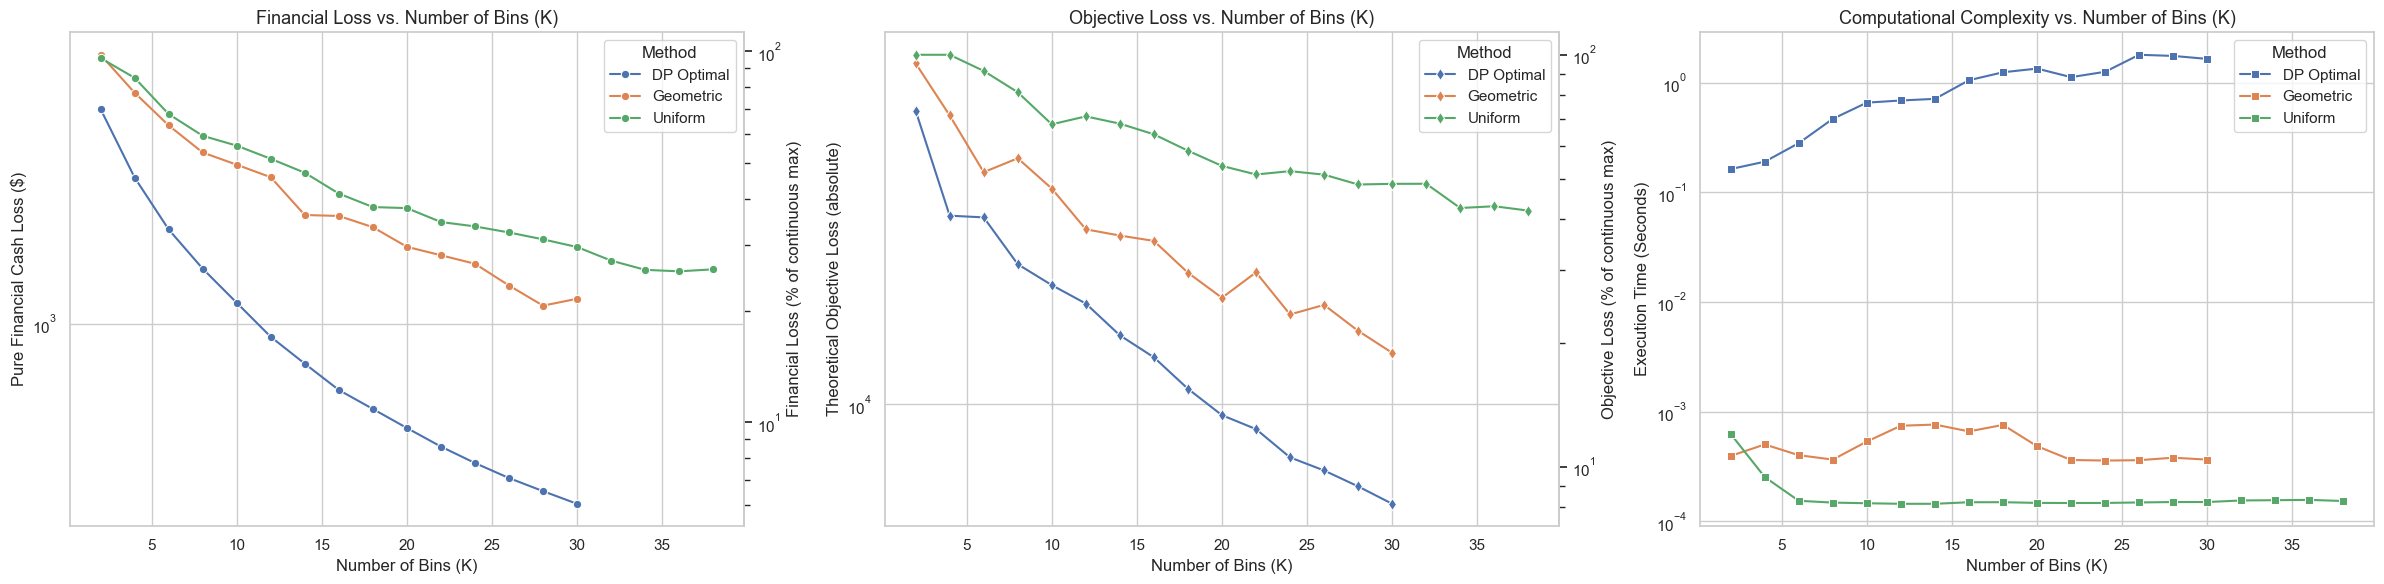

In [21]:
sns.set_theme(style="whitegrid")

full_k_summary = df_results[[
    'Method', 'K', 'Financial_Loss', 'Financial_Loss_pct',
    'Objective_Loss', 'Objective_Loss_pct', 'Execution_Time_sec', 'Improvement_pct',
]].sort_values(['Method', 'K']).reset_index(drop=True)
display(full_k_summary)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# --- Plot 1: Financial Loss Convergence (v-space) ---
sns.lineplot(data=df_results, x='K', y='Financial_Loss', hue='Method', marker='o', ax=axes[0])
axes[0].set_title("Financial Loss vs. Number of Bins (K)", fontsize=13)
axes[0].set_xlabel("Number of Bins (K)")
axes[0].set_ylabel("Pure Financial Cash Loss ($)")
axes[0].set_yscale('log')
sec_ax0 = axes[0].secondary_yaxis(
    'right',
    functions=(
        lambda y: (y / max_financial_continuous) * 100,
        lambda p: (p / 100) * max_financial_continuous,
    ),
)
sec_ax0.set_ylabel("Financial Loss (% of continuous max)")

# --- Plot 2: Objective Loss Convergence (phi-space) ---
sns.lineplot(data=df_results, x='K', y='Objective_Loss', hue='Method', marker='d', ax=axes[1])
axes[1].set_title("Objective Loss vs. Number of Bins (K)", fontsize=13)
axes[1].set_xlabel("Number of Bins (K)")
axes[1].set_ylabel("Theoretical Objective Loss (absolute)")
axes[1].set_yscale('log')
sec_ax1 = axes[1].secondary_yaxis(
    'right',
    functions=(
        lambda y: (y / max_objective_continuous) * 100,
        lambda p: (p / 100) * max_objective_continuous,
    ),
)
sec_ax1.set_ylabel("Objective Loss (% of continuous max)")

# --- Plot 3: Time Complexity (Scalability) ---
sns.lineplot(data=df_results, x='K', y='Execution_Time_sec', hue='Method', marker='s', ax=axes[2])
axes[2].set_title("Computational Complexity vs. Number of Bins (K)", fontsize=13)
axes[2].set_xlabel("Number of Bins (K)")
axes[2].set_ylabel("Execution Time (Seconds)")
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## Convergence Study — Interpretation

**Financial loss (left).** All three methods improve as K grows, but at very different rates. DP starts far below the heuristics even at K=2 and keeps improving ~7–35 % per step throughout the entire range, it hits the hard `max_k=30` cap before the early-stopping threshold ever fires. Uniform and Geometric plateau much sooner; both exit via the 0.1 % threshold, which is triggered when their loss marginally oscillates upward (negative improvement), not when it gracefully asymptotes.

**Objective loss (centre).** The same hierarchy holds in phi_rate space. The gap is larger than in financial loss because high-priority jobs (large q_j) receive amplified weight, so misplacing bins in the high-value tail costs disproportionately more in the objective score.

**Execution time (right).** Uniform and Geometric are O(N log N), essentially free at any K. DP is O(K·N²), its runtime grows visibly with K, which is the sole reason it is capped at 30. The trade-off is clear: DP extracts far more value per bin, but each additional bin is orders of magnitude more expensive to compute.

---

After this analysis we will conduct the further observation with K = 16. Below the main reasons:

1. Look at the **Financial Loss vs. Number of Bins** graph. The DP Optimal curve (blue) drops violently from $K=2$ down to $K=16$, capturing the vast majority of the potential revenue. After $K=16$, the curve begins to flatten out. Moving from 16 to 30 doubles the number of bins but yields progressively smaller marginal financial gains. $K=16$ is the mathematical **elbow point** where we maximize ROI per bin.

2. At $K=16$, the DP Optimal grid completely crushes the baselines. The graphs show the DP loss is almost an **order of magnitude lower** than the Uniform and Geometric grids. The DP algorithm at $K=16$ performs better than the heuristics do at $K=30$ or $K=40$. We do not need a massive $K$ because the DP algorithm places the boundaries so intelligently.


3. In the DLENT model, agent's **Action Space** size is exactly equal to $K$.

- At $K=16$, the agent has a small, highly optimized set of choices. It will train fast and converge reliably.
- If we push to $K=30$ just to chase a tiny fraction of theoretical revenue, we **double the machine learning complexity**.
- Furthermore, given our 2,000-row sample size, $K=30$ would cause **"Bin Starvation"** (bins at the top end with 0 or 1 job in them), confusing the RL agent with empty states.
- Usuallu models are optimized to run on powers of 2 


---
## Analysis 1 — Macro Metrics: The Bottom Line at K=16

We fix K=16 and compare the three algorithms on three dimensions: pure financial revenue loss, algorithmic objective loss, and execution time. This is the executive summary that shows the cost of choosing the wrong grid.

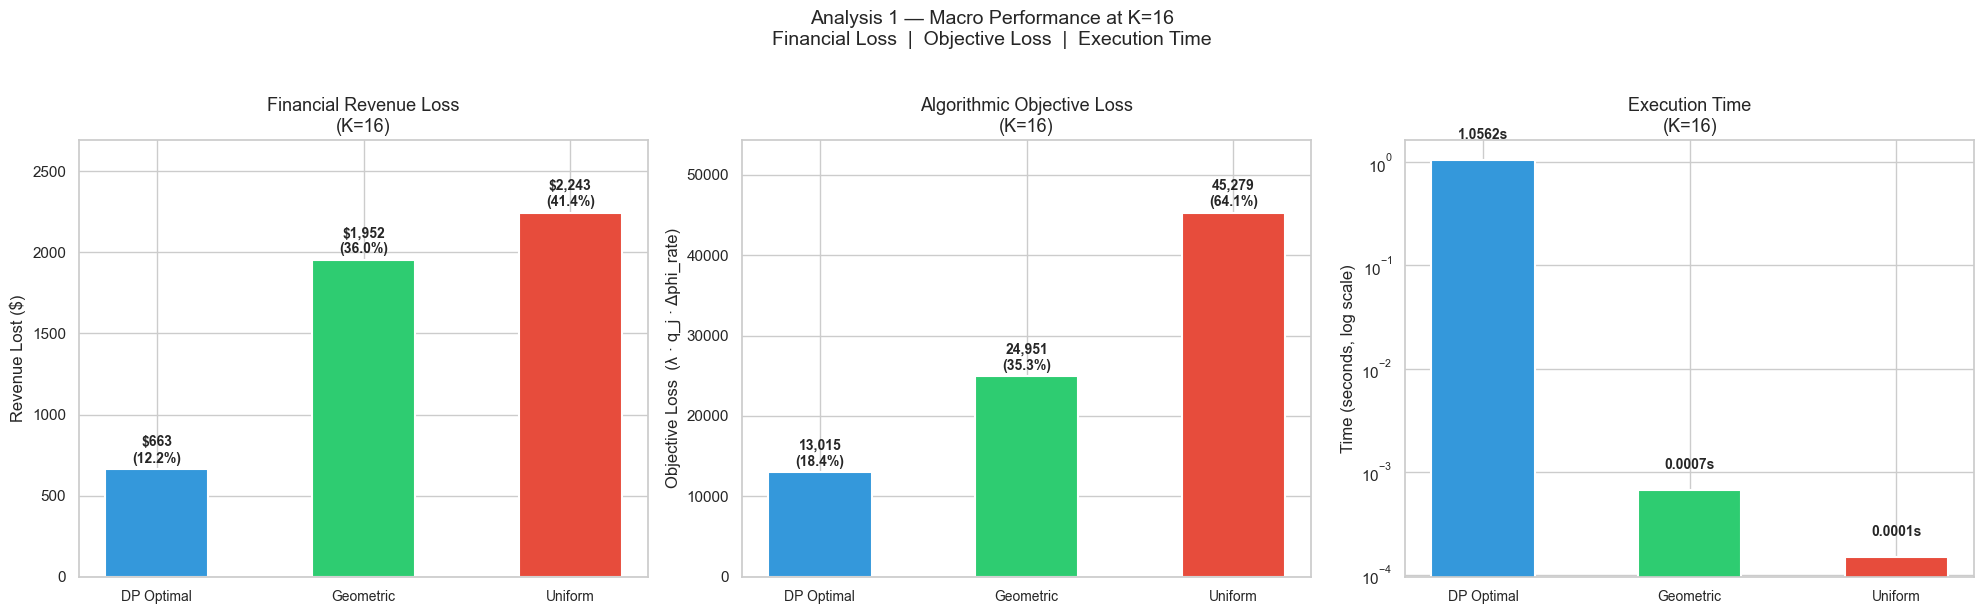

    Method  Financial_Loss  Financial_Loss_pct  Objective_Loss  Objective_Loss_pct  Execution_Time_sec
DP Optimal      662.977879           12.234370    13014.635007           18.427029            1.056211
 Geometric     1952.429347           36.029472    24951.020699           35.327398            0.000662
   Uniform     2243.241849           41.396028    45279.127767           64.109352            0.000150


In [22]:
K_REF = 16
k16 = df_results[df_results['K'] == K_REF].reset_index(drop=True)

METHODS  = k16['Method'].tolist()
COLORS   = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel 1: Financial Loss ($) ---
fin_vals = k16['Financial_Loss'].tolist()
bars = axes[0].bar(METHODS, fin_vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title(f'Financial Revenue Loss\n(K={K_REF})', fontsize=13)
axes[0].set_ylabel('Revenue Lost ($)')
axes[0].set_xlabel('')
for bar, val, pct in zip(bars, fin_vals, k16['Financial_Loss_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(fin_vals) * 0.01,
                 f'${val:,.0f}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(fin_vals) * 1.20)
axes[0].tick_params(axis='x', labelsize=10)

# --- Panel 2: Objective Loss ---
obj_vals = k16['Objective_Loss'].tolist()
bars = axes[1].bar(METHODS, obj_vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title(f'Algorithmic Objective Loss\n(K={K_REF})', fontsize=13)
axes[1].set_ylabel('Objective Loss  (λ · q_j · Δphi_rate)')
for bar, val, pct in zip(bars, obj_vals, k16['Objective_Loss_pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(obj_vals) * 0.01,
                 f'{val:,.0f}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(obj_vals) * 1.20)
axes[1].tick_params(axis='x', labelsize=10)

# --- Panel 3: Execution Time (log scale) ---
time_vals = k16['Execution_Time_sec'].tolist()
bars = axes[2].bar(METHODS, time_vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.5)
axes[2].set_title(f'Execution Time\n(K={K_REF})', fontsize=13)
axes[2].set_ylabel('Time (seconds, log scale)')
axes[2].set_yscale('log')
for bar, val in zip(bars, time_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.5,
                 f'{val:.4f}s',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].tick_params(axis='x', labelsize=10)

plt.suptitle(f'Analysis 1 — Macro Performance at K={K_REF}\nFinancial Loss  |  Objective Loss  |  Execution Time',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(k16[['Method', 'Financial_Loss', 'Financial_Loss_pct',
           'Objective_Loss', 'Objective_Loss_pct', 'Execution_Time_sec']].to_string(index=False))

**Reading the bars.** Each panel shows the same three methods side by side at K=16. Lower is better for all three metrics.

**Financial loss** measures how much real money the provider loses relative to a hypothetical continuous price menu. Uniform and Geometric lose a large fraction of possible revenue — they use their 16 bins inefficiently, wasting resolution on sparsely populated regions of the value space. DP minimises the loss function directly, so its bar is dramatically shorter: it finds the placement of boundaries that captures the most revenue given exactly 16 bins.

**Objective loss** tells the same story for the mechanism's internal algorithmic metric (λ · q_j · Δphi_rate). High-priority jobs (large q_j) get amplified weight, so misplacing bins in the high-phi_rate region is disproportionately costly. The DP's advantage tends to be even larger here.

**Execution time** is the cost of quality. Uniform and Geometric run in microseconds regardless of K. DP is O(K · N²) — already orders of magnitude slower at K=16, and growing quadratically with N. This is the practical engineering trade-off: DP is the right choice for offline, pre-computed price menus; the heuristics are appropriate for real-time or frequent recomputation.

---
## Analysis 2 — Boundary Placement

We overlay the KDE (probability density) of the dataset's `phi_rate` values with vertical lines showing exactly where each algorithm places its K=16 bin boundaries. This makes the algorithms' strategies visually self-evident.

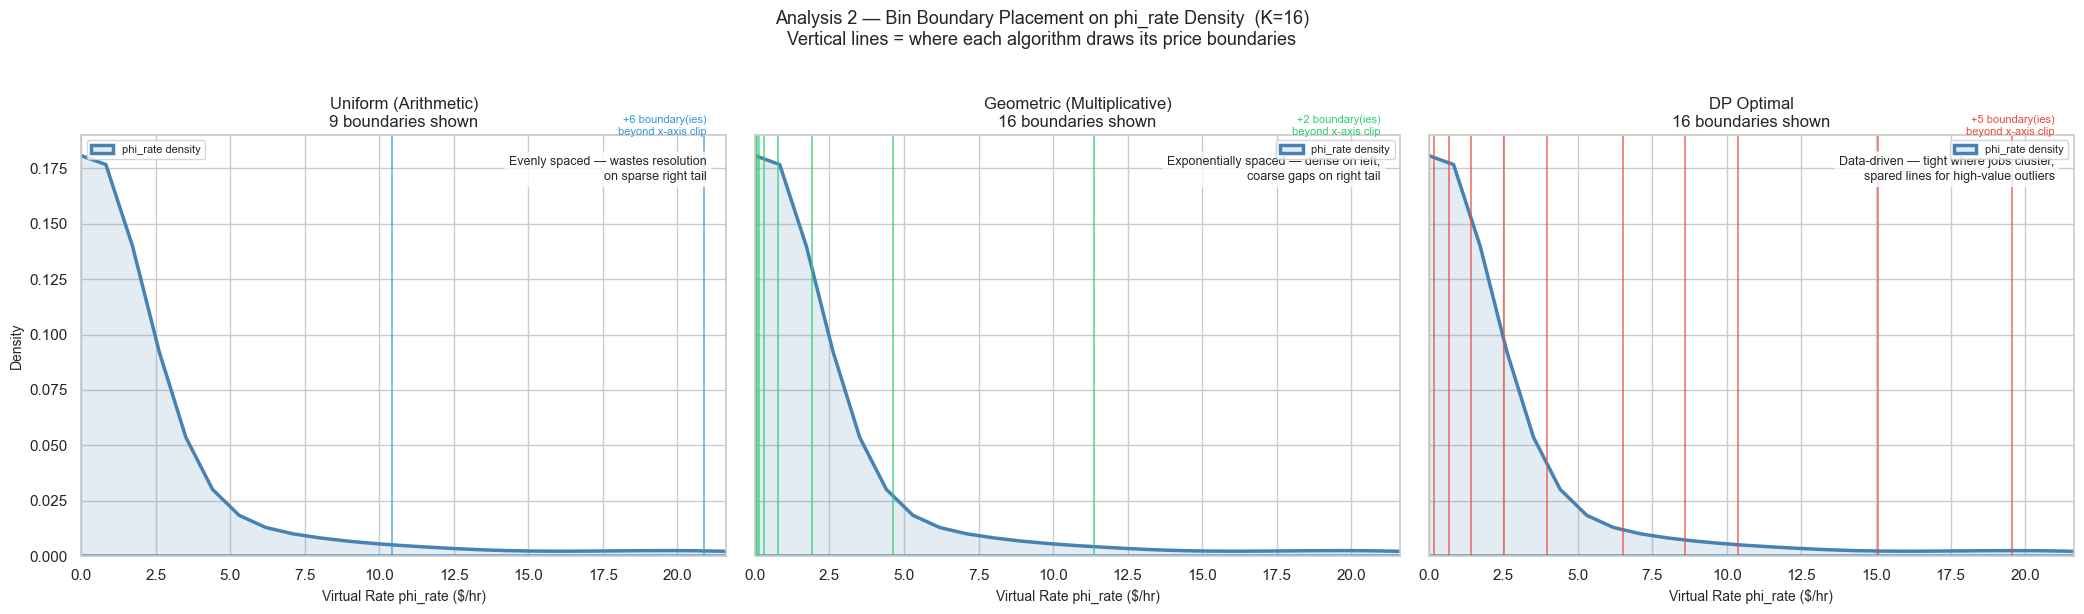

Uniform   boundaries: [  0.      10.4398  20.8797  31.3195  41.7593  52.1992  62.639   93.9585
 156.5975]
Geometric boundaries: [1.00000e-04 2.00000e-04 6.00000e-04 1.50000e-03 3.60000e-03 8.80000e-03
 2.16000e-02 5.28000e-02 1.29200e-01 3.16500e-01 7.74900e-01 1.89750e+00
 4.64630e+00 1.13772e+01 2.78588e+01 6.82162e+01]
DP        boundaries: [  0.       0.191    0.6721   1.424    2.5391   3.9622   6.5204   8.6034
  10.3643  15.0517  19.5745  28.6165  36.2916  59.8601  95.5139 167.0373]


In [23]:
K_REF = 16
disc_ref = Discretizer(K_bins=K_REF)

# The unique assigned prices ARE the K bin lower bounds for each algorithm
unif_boundaries = np.unique(disc_ref.uniform_grid(phi_continuous))
geom_boundaries = np.unique(disc_ref.geometric_grid(phi_continuous))
dp_boundaries   = np.unique(disc_ref.dp_optimal_grid(phi_continuous))

# Clip x-axis at 98th percentile so the dense region is clearly visible
x_clip = np.percentile(phi_continuous, 98)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

configs = [
    ('Uniform (Arithmetic)',     unif_boundaries, '#3498db',
     'Evenly spaced — wastes resolution\non sparse right tail'),
    ('Geometric (Multiplicative)', geom_boundaries, '#2ecc71',
     'Exponentially spaced — dense on left,\ncoarse gaps on right tail'),
    ('DP Optimal',               dp_boundaries,   '#e74c3c',
     'Data-driven — tight where jobs cluster,\nspared lines for high-value outliers'),
]

for ax, (name, boundaries, color, note) in zip(axes, configs):
    # KDE of the full phi_rate distribution
    sns.kdeplot(phi_continuous, ax=ax, color='steelblue', linewidth=2.5,
                fill=True, alpha=0.15, label='phi_rate density')

    # Vertical boundary lines
    clipped = boundaries[boundaries <= x_clip]
    for b in clipped:
        ax.axvline(b, color=color, alpha=0.75, linewidth=1.2)
    # Mark any boundaries beyond the clip with a single arrow annotation
    n_beyond = (boundaries > x_clip).sum()
    if n_beyond:
        ax.annotate(f'+{n_beyond} boundary(ies)\nbeyond x-axis clip',
                    xy=(x_clip * 0.97, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.01),
                    fontsize=8, color=color, ha='right')

    ax.set_xlim(0, x_clip)
    ax.set_title(f'{name}\n{len(boundaries)} boundaries shown', fontsize=12)
    ax.set_xlabel('Virtual Rate phi_rate ($/hr)', fontsize=10)
    ax.set_ylabel('Density' if ax == axes[0] else '', fontsize=10)

    # Annotation with the strategy note
    ax.text(0.97, 0.95, note, transform=ax.transAxes,
            fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.legend(fontsize=8)

plt.suptitle(f'Analysis 2 — Bin Boundary Placement on phi_rate Density  (K={K_REF})\n'
             f'Vertical lines = where each algorithm draws its price boundaries',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Uniform   boundaries: {np.round(unif_boundaries, 4)}")
print(f"Geometric boundaries: {np.round(geom_boundaries, 4)}")
print(f"DP        boundaries: {np.round(dp_boundaries, 4)}")

**How to read the plot.** The blue filled curve is the empirical density of `phi_rate` across all accepted jobs. The vertical coloured lines mark where each algorithm places its K=16 bin boundaries. Ideally, boundaries should be dense where the curve is tall and sparse where it is flat.

**Uniform (blue lines).** Bins are 10.44 $/hr wide, evenly spaced from 0 to 167. Because p95 of `phi_rate` is only ~10.73, all but one boundary fall in the near-empty right tail. The result: 7 of 16 bins are completely empty (no jobs assigned), and ~1,300 jobs are all lumped into the single leftmost bin at price ≈ 0. You will see fewer than 16 visible lines because lines landing in empty regions of the distribution have no visual effect on the job assignments.

**Geometric (green lines).** Boundaries are multiplicatively spaced, so they are denser near zero and exponentially wider toward the right. All 16 bins are populated, which is an improvement, but the last few bins cover enormous value ranges — the handful of whale jobs at the far right all share one coarse bin far below their true virtual rate.

**DP Optimal (red lines).** All 16 bins are populated and boundary placement is data-driven: tight lines in the high-density left cluster (serving mice with precision), with boundaries deliberately reserved for the high-value right tail to catch specific whale outliers. This is the mathematically optimal placement — and it is visually self-evident.

---
## Analysis 3 — Whale Error Breakdown

We split the accepted jobs into **Mice** (bottom 95% by `v_rate`) and **Whales** (top 5% by `v_rate`) and compute the average per-job discretization error in `phi_rate` space for each group under each algorithm. This proves that Uniform fails on Mice, Geometric fails on Whales, and only DP minimises both simultaneously.

Mice  (bottom 95%, v_rate ≤ 21.0778): 1331 jobs
Whales (top 5%,   v_rate >  21.0778): 71 jobs


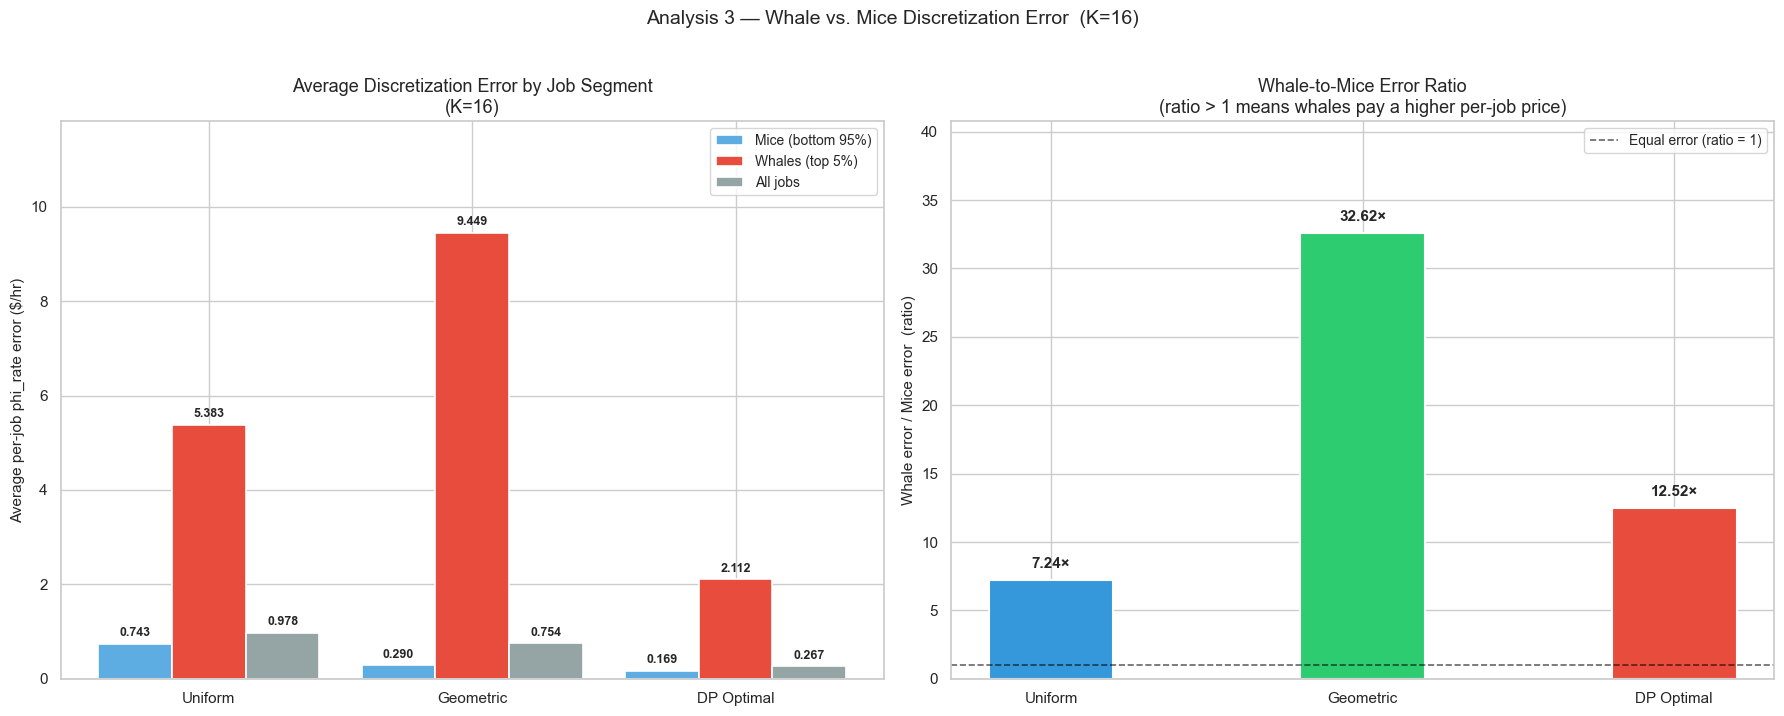

,Method,Mice avg error,Whale avg error,Total avg error,Whale/Mice ratio
0,Uniform,0.743199,5.382877,0.978161,7.242850
1,Geometric,0.289699,9.448948,0.753541,32.616451
2,DP Optimal,0.168728,2.111851,0.267132,12.516299


In [24]:
K_REF = 16
disc_ref = Discretizer(K_bins=K_REF)

# Split by v_rate: whales = top 5% most valuable jobs
threshold_95 = np.percentile(v_continuous, 95)
mice_mask  = v_continuous <= threshold_95
whale_mask = v_continuous >  threshold_95

print(f"Mice  (bottom 95%, v_rate ≤ {threshold_95:.4f}): {mice_mask.sum()} jobs")
print(f"Whales (top 5%,   v_rate >  {threshold_95:.4f}): {whale_mask.sum()} jobs")

# Compute per-job phi_rate discretization error for each method
methods_cfg = [
    ('Uniform',   disc_ref.uniform_grid,   '#3498db'),
    ('Geometric', disc_ref.geometric_grid, '#2ecc71'),
    ('DP Optimal',disc_ref.dp_optimal_grid,'#e74c3c'),
]

mice_avg_errors  = []
whale_avg_errors = []
total_avg_errors = []

for name, func, _ in methods_cfg:
    disc_phi = func(phi_continuous)           # same length as phi_continuous
    errors   = phi_continuous - disc_phi      # per-job loss (always ≥ 0 by design)
    mice_avg_errors.append(errors[mice_mask].mean())
    whale_avg_errors.append(errors[whale_mask].mean())
    total_avg_errors.append(errors.mean())

# --- Grouped bar chart ---
x     = np.arange(len(methods_cfg))
width = 0.28

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Mice vs Whale avg error per method
bars_m = axes[0].bar(x - width, mice_avg_errors,  width, label='Mice (bottom 95%)',
                     color='#5dade2', edgecolor='white', linewidth=1.2)
bars_w = axes[0].bar(x,          whale_avg_errors, width, label='Whales (top 5%)',
                     color='#e74c3c', edgecolor='white', linewidth=1.2)
bars_t = axes[0].bar(x + width,  total_avg_errors, width, label='All jobs',
                     color='#95a5a6', edgecolor='white', linewidth=1.2)

for bars, vals in [(bars_m, mice_avg_errors), (bars_w, whale_avg_errors), (bars_t, total_avg_errors)]:
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(whale_avg_errors) * 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels([c[0] for c in methods_cfg], fontsize=11)
axes[0].set_ylabel('Average per-job phi_rate error ($/hr)', fontsize=11)
axes[0].set_title(f'Average Discretization Error by Job Segment\n(K={K_REF})', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, max(whale_avg_errors) * 1.25)

# Panel 2: Whale-to-mice error ratio — shows which method is most unbalanced
ratios = [w / m if m > 0 else 0 for w, m in zip(whale_avg_errors, mice_avg_errors)]
bar_colors = [c[2] for c in methods_cfg]
bars_r = axes[1].bar([c[0] for c in methods_cfg], ratios,
                     color=bar_colors, edgecolor='white', linewidth=1.5, width=0.4)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Equal error (ratio = 1)')
for bar, val in zip(bars_r, ratios):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(ratios) * 0.02,
                 f'{val:.2f}×', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_ylabel('Whale error / Mice error  (ratio)', fontsize=11)
axes[1].set_title(f'Whale-to-Mice Error Ratio\n(ratio > 1 means whales pay a higher per-job price)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, max(ratios) * 1.25)
axes[1].tick_params(axis='x', labelsize=11)

plt.suptitle(f'Analysis 3 — Whale vs. Mice Discretization Error  (K={K_REF})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
summary_rows = []
for (name, _, _), me, we, te in zip(methods_cfg, mice_avg_errors, whale_avg_errors, total_avg_errors):
    summary_rows.append({'Method': name, 'Mice avg error': me, 'Whale avg error': we,
                         'Total avg error': te, 'Whale/Mice ratio': we / me if me > 0 else float('inf')})
display(pd.DataFrame(summary_rows))

**What the bars show.** The left panel reports the average per-job discretization error — i.e., `phi_rate_continuous − phi_rate_discrete` — separately for mice and whales. A taller bar means each job in that segment loses more because it is assigned a price that is further from its true virtual rate.

**Uniform fails the mice.** Because it spreads its bins uniformly across [min, max], the densely clustered low-`phi_rate` mice fall into just one or two coarse bins on the left. Each mouse suffers a relatively large average error relative to its true value.

**Geometric fails the whales.** The exponential spacing leaves an enormous gap at the top of the distribution. The handful of whale jobs — which contribute disproportionately to total revenue — all get assigned the same coarse bin price, far below their true virtual rate. The right panel (whale-to-mice ratio) makes this visible: a ratio much greater than 1 for Geometric means whales are being under-served by a large multiplier compared to mice.

**DP minimises both.** Because the DP objective directly minimises total sum-of-errors, it allocates boundaries where they reduce total loss the most — which naturally means serving both the dense left cluster (many jobs, low per-job impact) and the sparse right tail (few jobs, very high per-job impact). Its whale-to-mice ratio should be closest to 1, and both individual errors should be the lowest. This is the mathematical proof that DP is the only algorithm that does not systematically sacrifice either population.